# Penguins Palmer K Means Clustering

## Import Libraries

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

In [25]:
# load the penguins dataset
penguins = pd.read_csv('data/penguins.csv')
penguins.head()

,rowid,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [26]:
# check for unique values in species
penguins['species'].unique()

<ArrowStringArray>
['Adelie', 'Gentoo', 'Chinstrap']
Length: 3, dtype: str

In [27]:
# check for missing values
penguins.isnull().sum()

rowid                 0
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

In [28]:
# check for duplicates
penguins.duplicated().sum()

np.int64(0)

In [29]:
# analysis of missing values
penguins[penguins.isnull().any(axis=1)]

# drop the rows with missing values
penguins = penguins.dropna()

In [30]:
# remove the target variable and the non-numeric / id / non-physical columns
# (island and sex are strings; year is metadata with no bearing on morphology)
X = penguins.drop(columns=['species', 'island', 'sex', 'rowid', 'year'])
y = penguins['species']

print('X.shape: ', X.shape)
print('y.shape: ', y.shape)


X.shape:  (333, 4)
y.shape:  (333,)


In [31]:
# scale the data using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('X_scaled.shape: ', X_scaled.shape)

X_scaled.shape:  (333, 4)


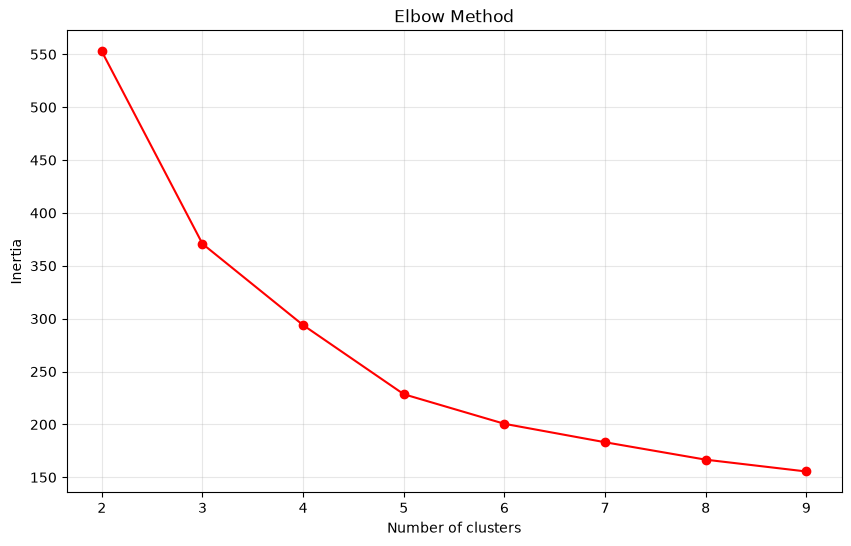

In [32]:
# choosing k: elbow method
inertia = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 10), inertia, "o-", color='red')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(range(2, 10))
plt.grid(alpha=0.3)
plt.show()


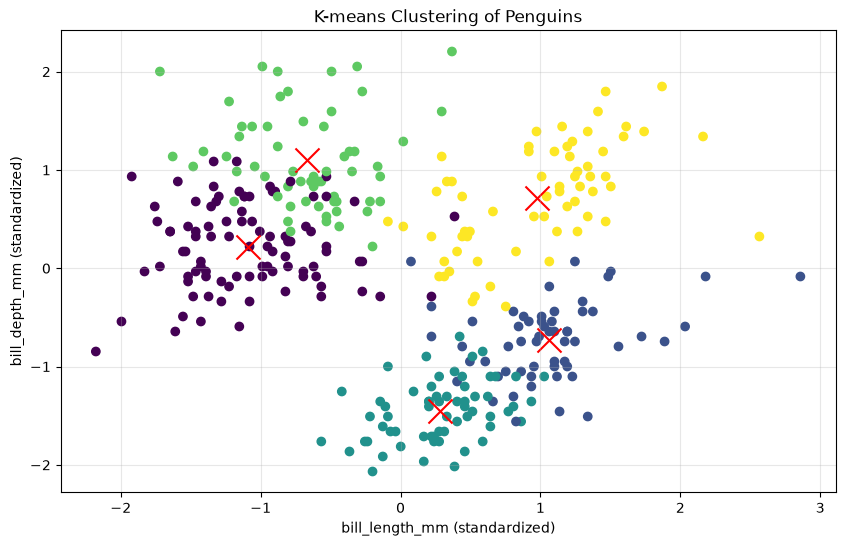

In [33]:
kmeans_penguins = KMeans(n_clusters=5, random_state=42, n_init=10)
y_penguins_pred = kmeans_penguins.fit_predict(X_scaled)

# plot the clusters
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_penguins_pred, cmap='viridis')
plt.scatter(kmeans_penguins.cluster_centers_[:, 0], kmeans_penguins.cluster_centers_[:, 1], s=300, c='red', marker='x')
plt.xlabel('bill_length_mm (standardized)')
plt.ylabel('bill_depth_mm (standardized)')
plt.title('K-means Clustering of Penguins')
plt.grid(alpha=0.3)
plt.show()

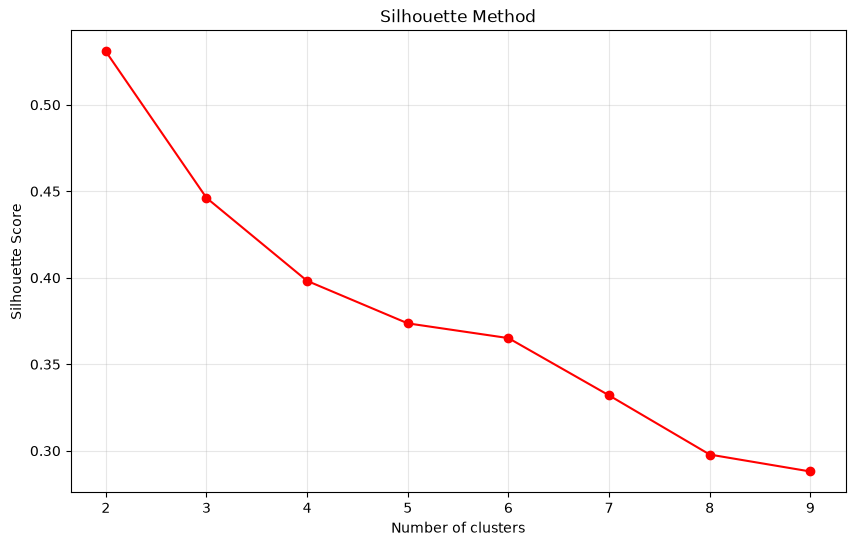

In [34]:
# choosing k: silhouette method
silhouette_scores = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    y_pred = kmeans.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, y_pred))

plt.figure(figsize=(10, 6))
plt.plot(range(2, 10), silhouette_scores, "o-", color='red')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method')
plt.xticks(range(2, 10))
plt.grid(alpha=0.3)
plt.show()

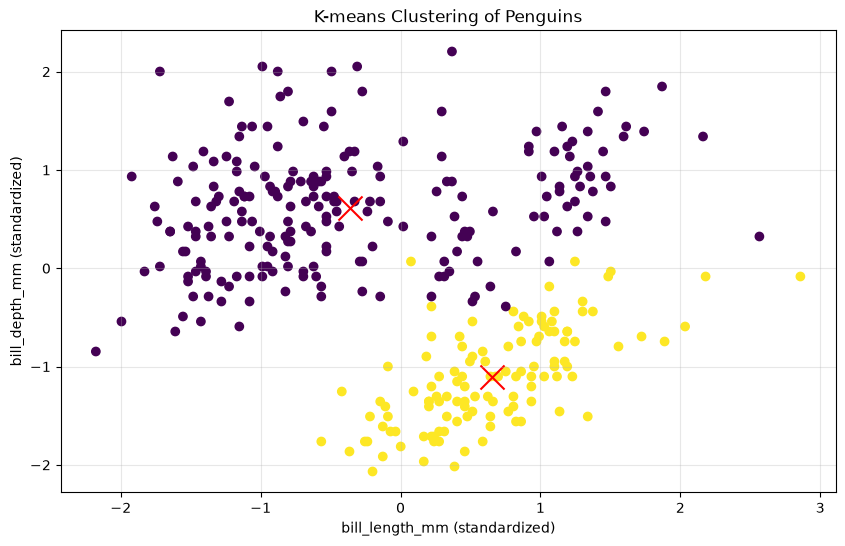

In [35]:
kmeans_penguins = KMeans(n_clusters=2, random_state=42, n_init=10)
y_penguins_pred = kmeans_penguins.fit_predict(X_scaled)

# plot the clusters
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_penguins_pred, cmap='viridis')
plt.scatter(kmeans_penguins.cluster_centers_[:, 0], kmeans_penguins.cluster_centers_[:, 1], s=300, c='red', marker='x')
plt.xlabel('bill_length_mm (standardized)')
plt.ylabel('bill_depth_mm (standardized)')
plt.title('K-means Clustering of Penguins')
plt.grid(alpha=0.3)
plt.show()

### Feature selection matters as much as choosing k

Above, the aggregate silhouette method prefers `k=2` even after dropping `year`, because
Gentoo is very distinct while Adelie and Chinstrap overlap heavily in flipper length and
body mass — so the one feature that separates Adelie/Chinstrap well (bill shape) gets
diluted. To test that, we compare the silhouette curves for all four measurements vs. just
the two bill dimensions.

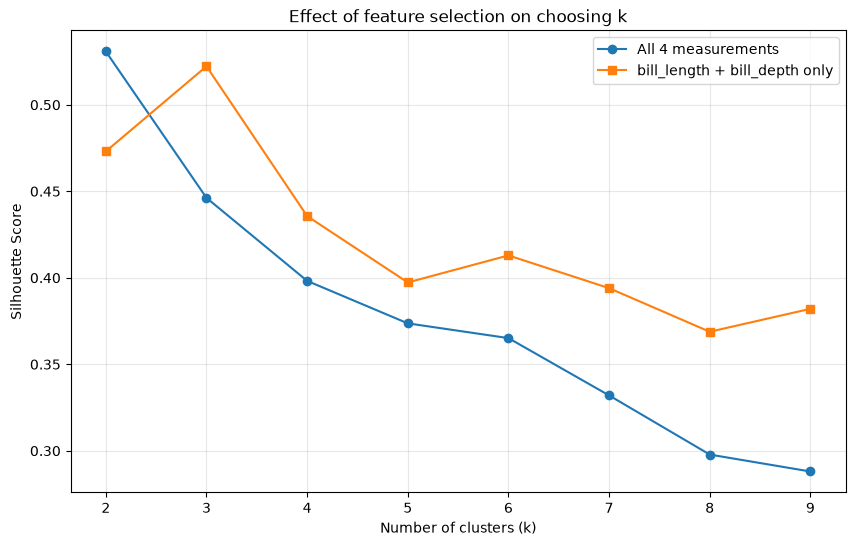

In [36]:
feat_all = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
feat_bill = ['bill_length_mm', 'bill_depth_mm']

K = range(2, 10)
sil_all, sil_bill = [], []
for k in K:
    X_all = StandardScaler().fit_transform(penguins[feat_all])
    X_bill = StandardScaler().fit_transform(penguins[feat_bill])
    sil_all.append(silhouette_score(X_all, KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_all)))
    sil_bill.append(silhouette_score(X_bill, KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_bill)))

plt.figure(figsize=(10, 6))
plt.plot(K, sil_all, 'o-', label='All 4 measurements')
plt.plot(K, sil_bill, 's-', label='bill_length + bill_depth only')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Effect of feature selection on choosing k')
plt.xticks(K)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Silhouette score (k=3, bill features only): 0.522
True species vs. predicted cluster:
col_0       0    1    2
species                
Adelie      4  142    0
Chinstrap  54    5    9
Gentoo      6    1  112


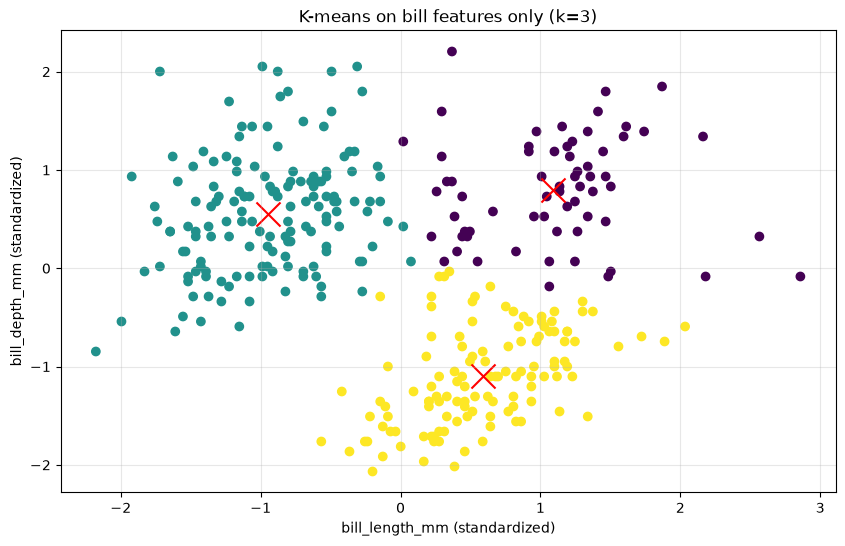

In [37]:
X_bill = StandardScaler().fit_transform(penguins[feat_bill])

kmeans_bill = KMeans(n_clusters=3, random_state=42, n_init=10)
y_bill_pred = kmeans_bill.fit_predict(X_bill)

print(f"Silhouette score (k=3, bill features only): {silhouette_score(X_bill, y_bill_pred):.3f}")
print('True species vs. predicted cluster:')
print(pd.crosstab(y, y_bill_pred))

plt.figure(figsize=(10, 6))
plt.scatter(X_bill[:, 0], X_bill[:, 1], c=y_bill_pred, cmap='viridis')
plt.scatter(kmeans_bill.cluster_centers_[:, 0], kmeans_bill.cluster_centers_[:, 1], s=300, c='red', marker='x')
plt.xlabel('bill_length_mm (standardized)')
plt.ylabel('bill_depth_mm (standardized)')
plt.title('K-means on bill features only (k=3)')
plt.grid(alpha=0.3)
plt.show()

**Insight:** with only the two bill dimensions, `k=3` becomes the clear winner (silhouette
~0.52) and the species-vs-cluster confusion matrix becomes almost perfectly diagonal — each
species lands mostly in its own cluster. Flipper length and body mass are what blurred
Adelie and Chinstrap together, so choosing informative features can matter as much as
choosing the right `k`.